# Assignment 6

This notebook trains a deterministic ResidualSegNet and a Bayesian ResidualSegNet on the salt segmentation dataset. The notebook is organized so that model definitions live in standalone Python modules, training is separated from plotting, and every figure is saved to disk for reporting.

In [1]:
from pathlib import Path
import time

import torch
import torch.nn as nn
import torchbnn as bnn
from IPython.display import Image, display

from assignment6_models import BayesianResidualSegNet, ResidualSegNet
from assignment6_utils import (
    SaltDataset,
    ensure_dir,
    fit_model,
    get_device,
    make_loaders,
    mc_predict,
    plot_bayesian_predictions,
    plot_deterministic_predictions,
    plot_history,
    plot_sample_batch,
    run_epoch,
    save_history_csv,
    save_json,
    segmentation_metrics,
    set_seed,
    split_image_paths,
)

torch.set_float32_matmul_precision("high")
set_seed(42, deterministic=False)
device = get_device(require_cuda=True)
amp_enabled = device.type == "cuda"
criterion = nn.BCEWithLogitsLoss()
kl_loss_fn = bnn.BKLLoss(reduction="mean", last_layer_only=False)
kl_weight = 5e-5

DATA_ROOT = Path("./Salt")
IMAGE_DIR = DATA_ROOT / "images"
MASK_DIR = DATA_ROOT / "masks"
IMG_SIZE = 128

OUTPUT_ROOT = ensure_dir(Path("./outputs"))
FIGURE_DIR = ensure_dir(OUTPUT_ROOT / "figures")
MODEL_DIR = ensure_dir(OUTPUT_ROOT / "models")
METRIC_DIR = ensure_dir(OUTPUT_ROOT / "metrics")

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Models will be saved to: {MODEL_DIR.resolve()}")
print(f"Metrics will be saved to: {METRIC_DIR.resolve()}")


Device: cuda
GPU: NVIDIA RTX 3500 Ada Generation Laptop GPU
Figures will be saved to: D:\KAUST\semster2\ML_IN_GEO\assignmnet6\outputs\figures
Models will be saved to: D:\KAUST\semster2\ML_IN_GEO\assignmnet6\outputs\models
Metrics will be saved to: D:\KAUST\semster2\ML_IN_GEO\assignmnet6\outputs\metrics


Train samples: 3200
Validation samples: 400
Test samples: 400
Saved sample figure to: outputs\figures\sample_batch.png


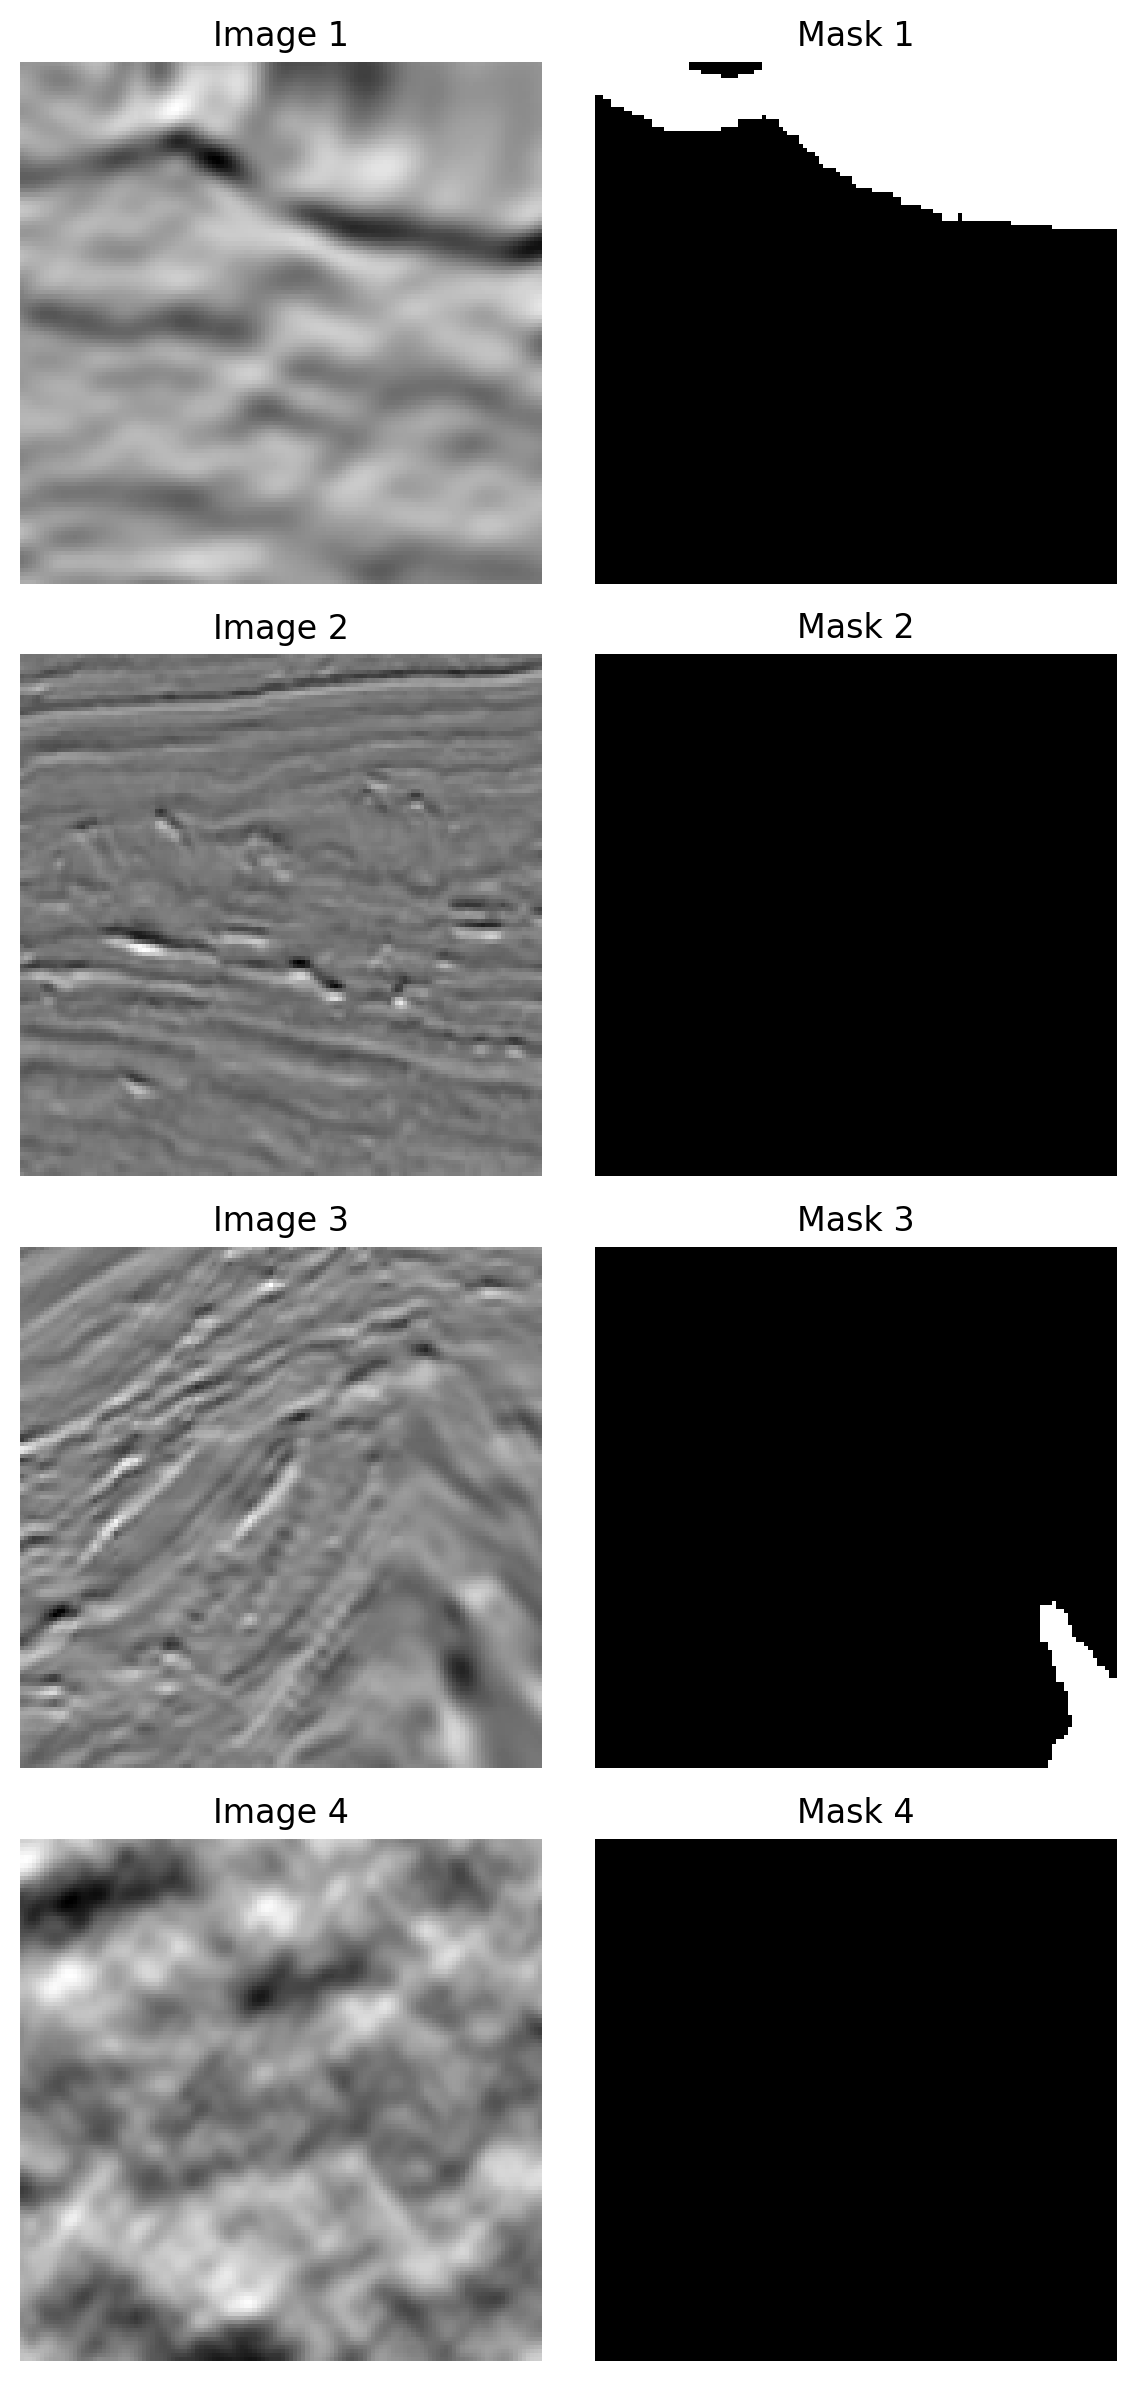

In [2]:
train_paths, val_paths, test_paths = split_image_paths(IMAGE_DIR, seed=42)
print(f"Train samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")

sample_dataset = SaltDataset(train_paths[:4], MASK_DIR, IMG_SIZE)
sample_figure_path = plot_sample_batch(sample_dataset, FIGURE_DIR / "sample_batch.png", num_examples=min(4, len(sample_dataset)))
print(f"Saved sample figure to: {sample_figure_path}")
display(Image(filename=str(sample_figure_path)))


## Deterministic Model Search

In [3]:
search_space = [
    {"base_channels": 16, "dropout": 0.05, "lr": 1e-3, "weight_decay": 1e-5, "batch_size": 32},
    {"base_channels": 16, "dropout": 0.10, "lr": 5e-4, "weight_decay": 1e-4, "batch_size": 32},
    {"base_channels": 24, "dropout": 0.10, "lr": 5e-4, "weight_decay": 1e-5, "batch_size": 16},
]

search_epochs = 10
search_results = []

for config in search_space:
    print("\nSearching config:", config)
    train_loader, val_loader, _ = make_loaders(
        train_paths=train_paths,
        val_paths=val_paths,
        test_paths=test_paths,
        mask_dir=MASK_DIR,
        image_size=IMG_SIZE,
        batch_size=config["batch_size"],
        device=device,
    )
    model = ResidualSegNet(base_channels=config["base_channels"], dropout=config["dropout"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    start = time.time()
    _, history, best_val_iou = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        device=device,
        optimizer=optimizer,
        epochs=search_epochs,
        amp_enabled=amp_enabled,
        label="Search epoch",
    )
    elapsed_minutes = (time.time() - start) / 60.0

    result = dict(config)
    result["best_val_iou"] = best_val_iou
    result["minutes"] = elapsed_minutes
    result["history"] = history
    search_results.append(result)

best_config = max(search_results, key=lambda item: item["best_val_iou"])
search_results = sorted(search_results, key=lambda item: item["best_val_iou"], reverse=True)

print("\nValidation IoU ranking:")
for row in search_results:
    print({k: row[k] for k in row if k != "history"})

save_json(search_results, METRIC_DIR / "deterministic_search_results.json")
print("\nBest config:")
print({k: best_config[k] for k in best_config if k != "history"})



Searching config: {'base_channels': 16, 'dropout': 0.05, 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 32}


d:\KAUST\semster2\ML_IN_GEO\assignmnet6\assignment6_utils.py:141: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return torch.cuda.amp.GradScaler(enabled=amp_enabled and device.type == "cuda")


Search epoch 01/10 | train loss=0.5726, train IoU=0.3735 | val loss=0.5544, val IoU=0.3846
Search epoch 02/10 | train loss=0.5574, train IoU=0.3856 | val loss=0.5446, val IoU=0.3846
Search epoch 03/10 | train loss=0.5532, train IoU=0.3856 | val loss=0.5517, val IoU=0.3846
Search epoch 04/10 | train loss=0.5582, train IoU=0.3856 | val loss=0.5474, val IoU=0.3846
Search epoch 05/10 | train loss=0.5209, train IoU=0.3821 | val loss=0.4052, val IoU=0.4816
Search epoch 06/10 | train loss=0.4099, train IoU=0.4788 | val loss=0.3533, val IoU=0.5219
Search epoch 07/10 | train loss=0.3679, train IoU=0.5148 | val loss=0.3252, val IoU=0.5503
Search epoch 08/10 | train loss=0.3464, train IoU=0.5564 | val loss=0.3102, val IoU=0.5727
Search epoch 09/10 | train loss=0.3259, train IoU=0.5714 | val loss=0.3337, val IoU=0.5864
Search epoch 10/10 | train loss=0.3090, train IoU=0.5815 | val loss=0.2707, val IoU=0.5800

Searching config: {'base_channels': 16, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 0.0

## Deterministic Final Training

In [4]:
final_epochs = 30
train_loader, val_loader, test_loader = make_loaders(
    train_paths=train_paths,
    val_paths=val_paths,
    test_paths=test_paths,
    mask_dir=MASK_DIR,
    image_size=IMG_SIZE,
    batch_size=best_config["batch_size"],
    device=device,
)

det_model = ResidualSegNet(
    base_channels=best_config["base_channels"],
    dropout=best_config["dropout"],
).to(device)
det_optimizer = torch.optim.AdamW(
    det_model.parameters(),
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"],
)

det_best_state, det_history, det_best_val_iou = fit_model(
    model=det_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    optimizer=det_optimizer,
    epochs=final_epochs,
    amp_enabled=amp_enabled,
    label="Deterministic epoch",
)
det_model.load_state_dict(det_best_state)

torch.save(det_best_state, MODEL_DIR / "residual_segnet_best.pth")
save_history_csv(det_history, METRIC_DIR / "deterministic_history.csv")
save_json(
    {
        "config": {k: best_config[k] for k in best_config if k != "history"},
        "best_val_iou": det_best_val_iou,
        "epochs": final_epochs,
    },
    METRIC_DIR / "deterministic_training_summary.json",
)
print("Saved deterministic model and training history.")


Deterministic epoch 01/30 | train loss=0.5637, train IoU=0.3856 | val loss=0.5524, val IoU=0.3750
Deterministic epoch 02/30 | train loss=0.5483, train IoU=0.3856 | val loss=0.4720, val IoU=0.3750
Deterministic epoch 03/30 | train loss=0.4584, train IoU=0.4576 | val loss=0.3738, val IoU=0.4990
Deterministic epoch 04/30 | train loss=0.3717, train IoU=0.5303 | val loss=0.3511, val IoU=0.4652
Deterministic epoch 05/30 | train loss=0.3409, train IoU=0.5663 | val loss=0.3191, val IoU=0.5692
Deterministic epoch 06/30 | train loss=0.3321, train IoU=0.5867 | val loss=0.2957, val IoU=0.6007
Deterministic epoch 07/30 | train loss=0.3083, train IoU=0.6097 | val loss=0.3089, val IoU=0.5409
Deterministic epoch 08/30 | train loss=0.3019, train IoU=0.6163 | val loss=0.2860, val IoU=0.6091
Deterministic epoch 09/30 | train loss=0.2943, train IoU=0.6199 | val loss=0.2585, val IoU=0.6175
Deterministic epoch 10/30 | train loss=0.2805, train IoU=0.6306 | val loss=0.2616, val IoU=0.6351
Deterministic epoch 

In [5]:
det_test_metrics = run_epoch(
    model=det_model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    amp_enabled=amp_enabled,
)
print("Deterministic ResidualSegNet test metrics")
print(f"Pixel accuracy: {det_test_metrics['acc']:.4f}")
print(f"IoU: {det_test_metrics['iou']:.4f}")

det_model.eval()
det_images, det_masks = next(iter(test_loader))
with torch.no_grad():
    with torch.autocast(device_type=device.type, enabled=amp_enabled):
        det_logits = det_model(det_images.to(device, non_blocking=device.type == "cuda"))
det_probs = torch.sigmoid(det_logits).cpu()

save_json(
    {
        "pixel_accuracy": det_test_metrics["acc"],
        "iou": det_test_metrics["iou"],
    },
    METRIC_DIR / "deterministic_test_metrics.json",
)


Deterministic ResidualSegNet test metrics
Pixel accuracy: 0.9321
IoU: 0.7437


WindowsPath('outputs/metrics/deterministic_test_metrics.json')

Saved deterministic history figure to: outputs\figures\deterministic_history.png
Saved deterministic prediction figure to: outputs\figures\deterministic_predictions.png


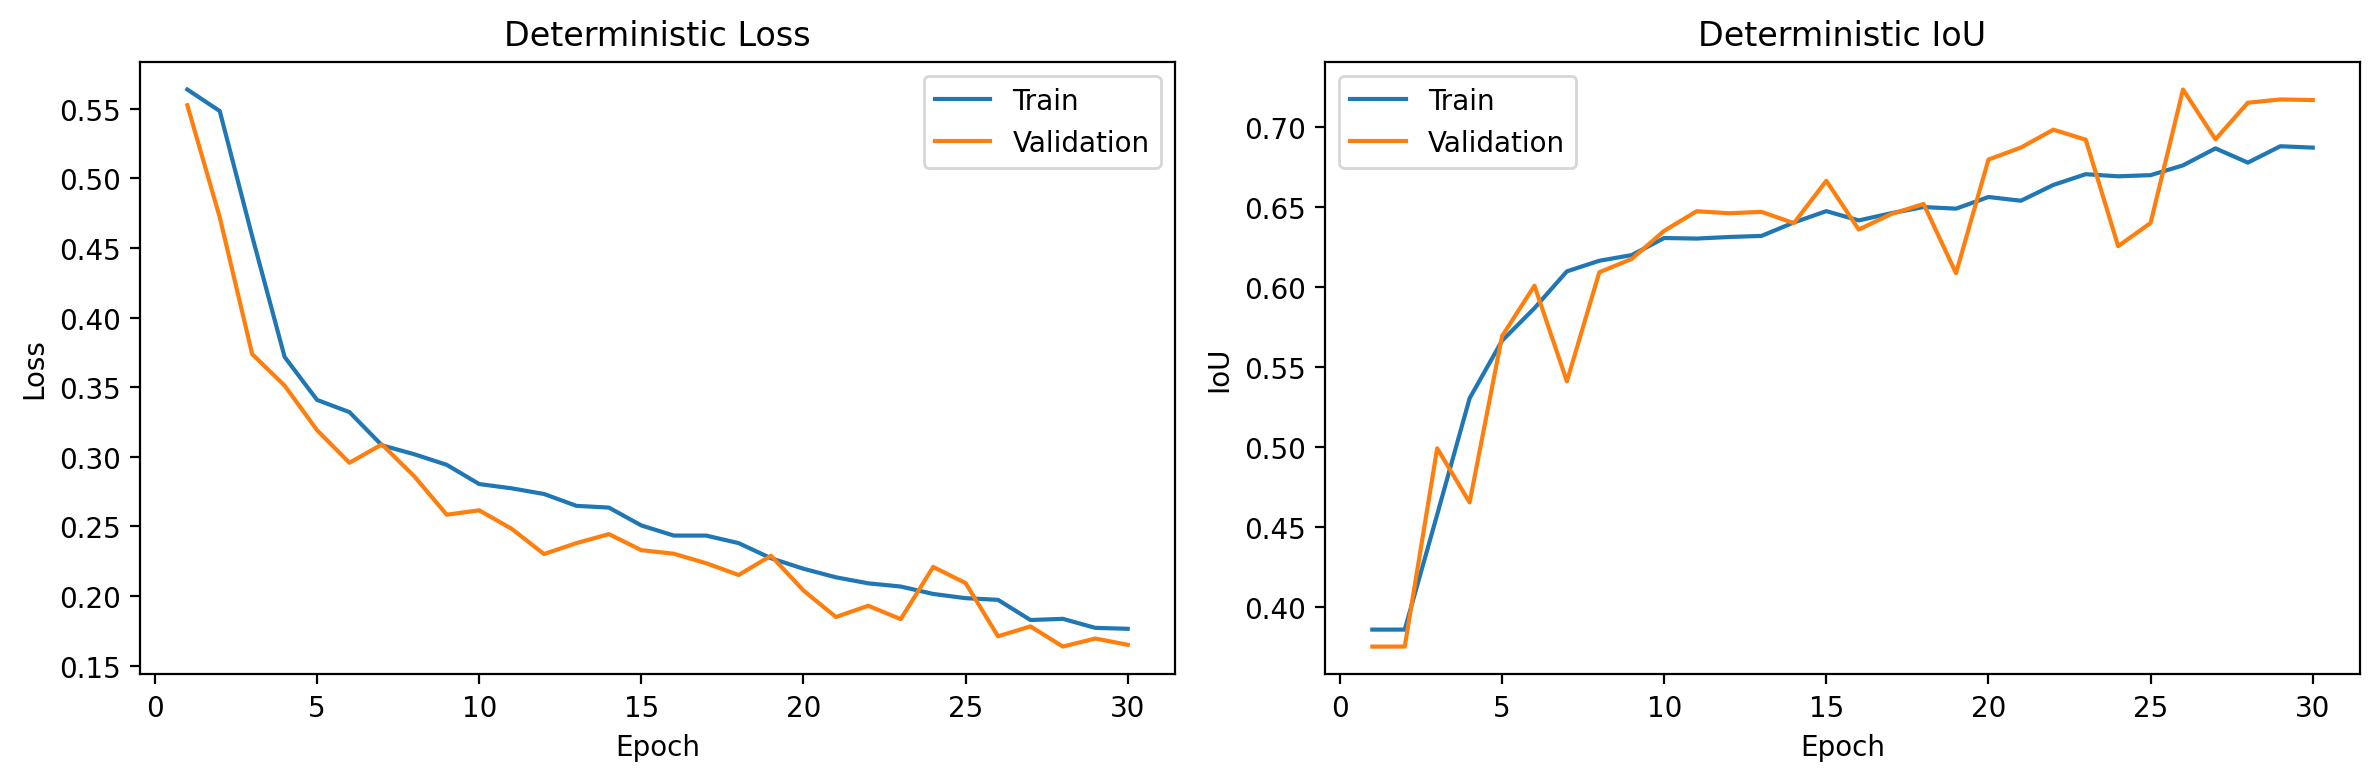

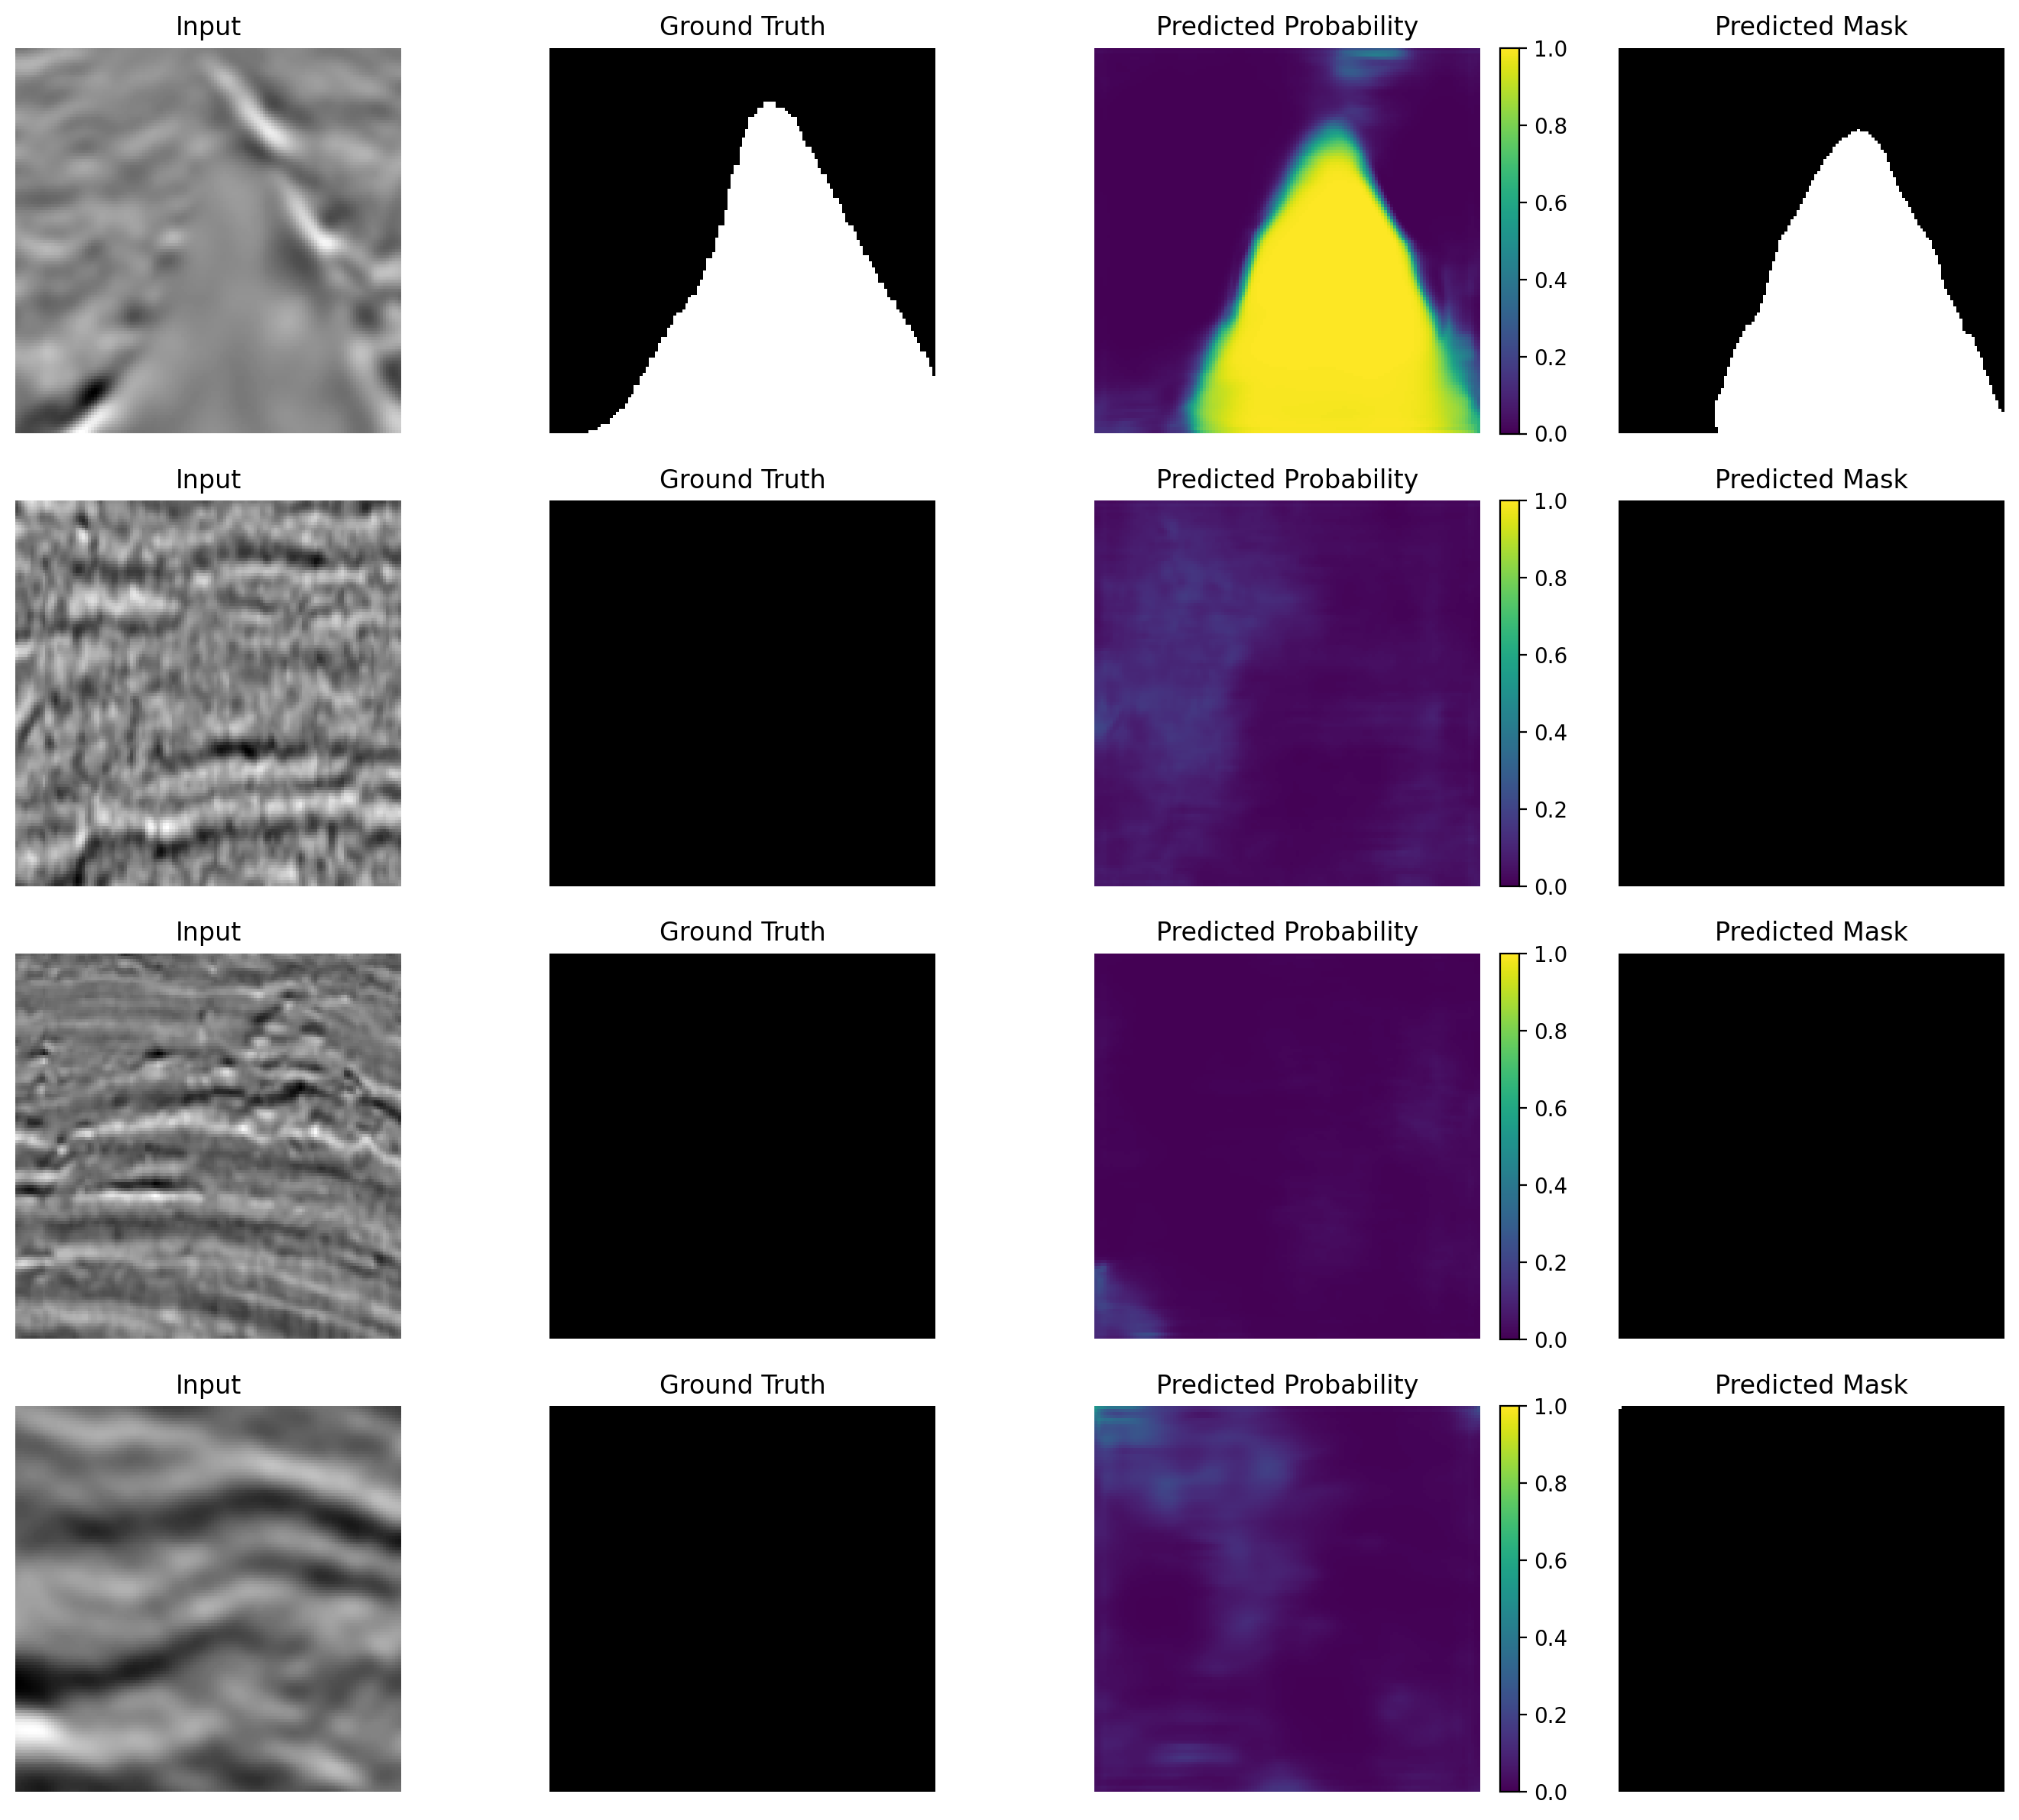

In [6]:
det_history_path = plot_history(det_history, FIGURE_DIR / "deterministic_history.png", title_prefix="Deterministic")
det_pred_path = plot_deterministic_predictions(det_images, det_masks, det_probs, FIGURE_DIR / "deterministic_predictions.png")
print(f"Saved deterministic history figure to: {det_history_path}")
print(f"Saved deterministic prediction figure to: {det_pred_path}")
display(Image(filename=str(det_history_path)))
display(Image(filename=str(det_pred_path)))


## Bayesian Training and Evaluation

In [13]:
bayesian_epochs = 20
bayesian_lr = best_config["lr"] * 0.5

def bayesian_extra_loss(model):
    return kl_weight * kl_loss_fn(model)

bayes_model = BayesianResidualSegNet(base_channels=best_config["base_channels"]).to(device)
bayes_optimizer = torch.optim.Adam(bayes_model.parameters(), lr=bayesian_lr)

bayes_best_state, bayes_history, bayes_best_val_iou = fit_model(
    model=bayes_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    optimizer=bayes_optimizer,
    epochs=bayesian_epochs,
    extra_loss_fn=bayesian_extra_loss,
    amp_enabled=amp_enabled,
    label="Bayesian epoch",
)
bayes_model.load_state_dict(bayes_best_state)

torch.save(bayes_best_state, MODEL_DIR / "bayesian_residual_segnet_best.pth")
save_history_csv(bayes_history, METRIC_DIR / "bayesian_history.csv")
save_json(
    {
        "base_channels": best_config["base_channels"],
        "lr": bayesian_lr,
        "kl_weight": kl_weight,
        "epochs": bayesian_epochs,
        "best_val_iou": bayes_best_val_iou,
    },
    METRIC_DIR / "bayesian_training_summary.json",
)
print("Saved Bayesian model and training history.")


Bayesian epoch 01/20 | train loss=0.6158, train IoU=0.2467 | val loss=0.6203, val IoU=0.3010
Bayesian epoch 02/20 | train loss=0.5869, train IoU=0.3507 | val loss=0.5745, val IoU=0.3650
Bayesian epoch 03/20 | train loss=0.5780, train IoU=0.3777 | val loss=0.5685, val IoU=0.3750
Bayesian epoch 04/20 | train loss=0.5720, train IoU=0.3856 | val loss=0.5846, val IoU=0.3750
Bayesian epoch 05/20 | train loss=0.5707, train IoU=0.3856 | val loss=0.5602, val IoU=0.3750
Bayesian epoch 06/20 | train loss=0.5660, train IoU=0.3856 | val loss=0.5654, val IoU=0.3750
Bayesian epoch 07/20 | train loss=0.5672, train IoU=0.3856 | val loss=0.5655, val IoU=0.3750
Bayesian epoch 08/20 | train loss=0.5631, train IoU=0.3856 | val loss=0.5589, val IoU=0.3750
Bayesian epoch 09/20 | train loss=0.5615, train IoU=0.3856 | val loss=0.5609, val IoU=0.3750
Bayesian epoch 10/20 | train loss=0.5656, train IoU=0.3856 | val loss=0.5565, val IoU=0.3750
Bayesian epoch 11/20 | train loss=0.5582, train IoU=0.3856 | val loss=

In [14]:
bayes_images, bayes_masks, bayes_mean_probs, bayes_std_probs = mc_predict(
    model=bayes_model,
    loader=test_loader,
    device=device,
    n_samples=20,
    amp_enabled=amp_enabled,
)
bayes_acc, bayes_iou = segmentation_metrics(bayes_mean_probs, bayes_masks)

print("Bayesian ResidualSegNet test metrics")
print(f"Pixel accuracy: {bayes_acc:.4f}")
print(f"IoU: {bayes_iou:.4f}")
print(f"Mean predictive std: {bayes_std_probs.mean().item():.4f}")

save_json(
    {
        "pixel_accuracy": bayes_acc,
        "iou": bayes_iou,
        "mean_predictive_std": bayes_std_probs.mean().item(),
    },
    METRIC_DIR / "bayesian_test_metrics.json",
)


Bayesian ResidualSegNet test metrics
Pixel accuracy: 0.7670
IoU: 0.4450
Mean predictive std: 0.0615


WindowsPath('outputs/metrics/bayesian_test_metrics.json')

Saved Bayesian history figure to: outputs\figures\bayesian_history.png
Saved Bayesian prediction figure to: outputs\figures\bayesian_predictions.png


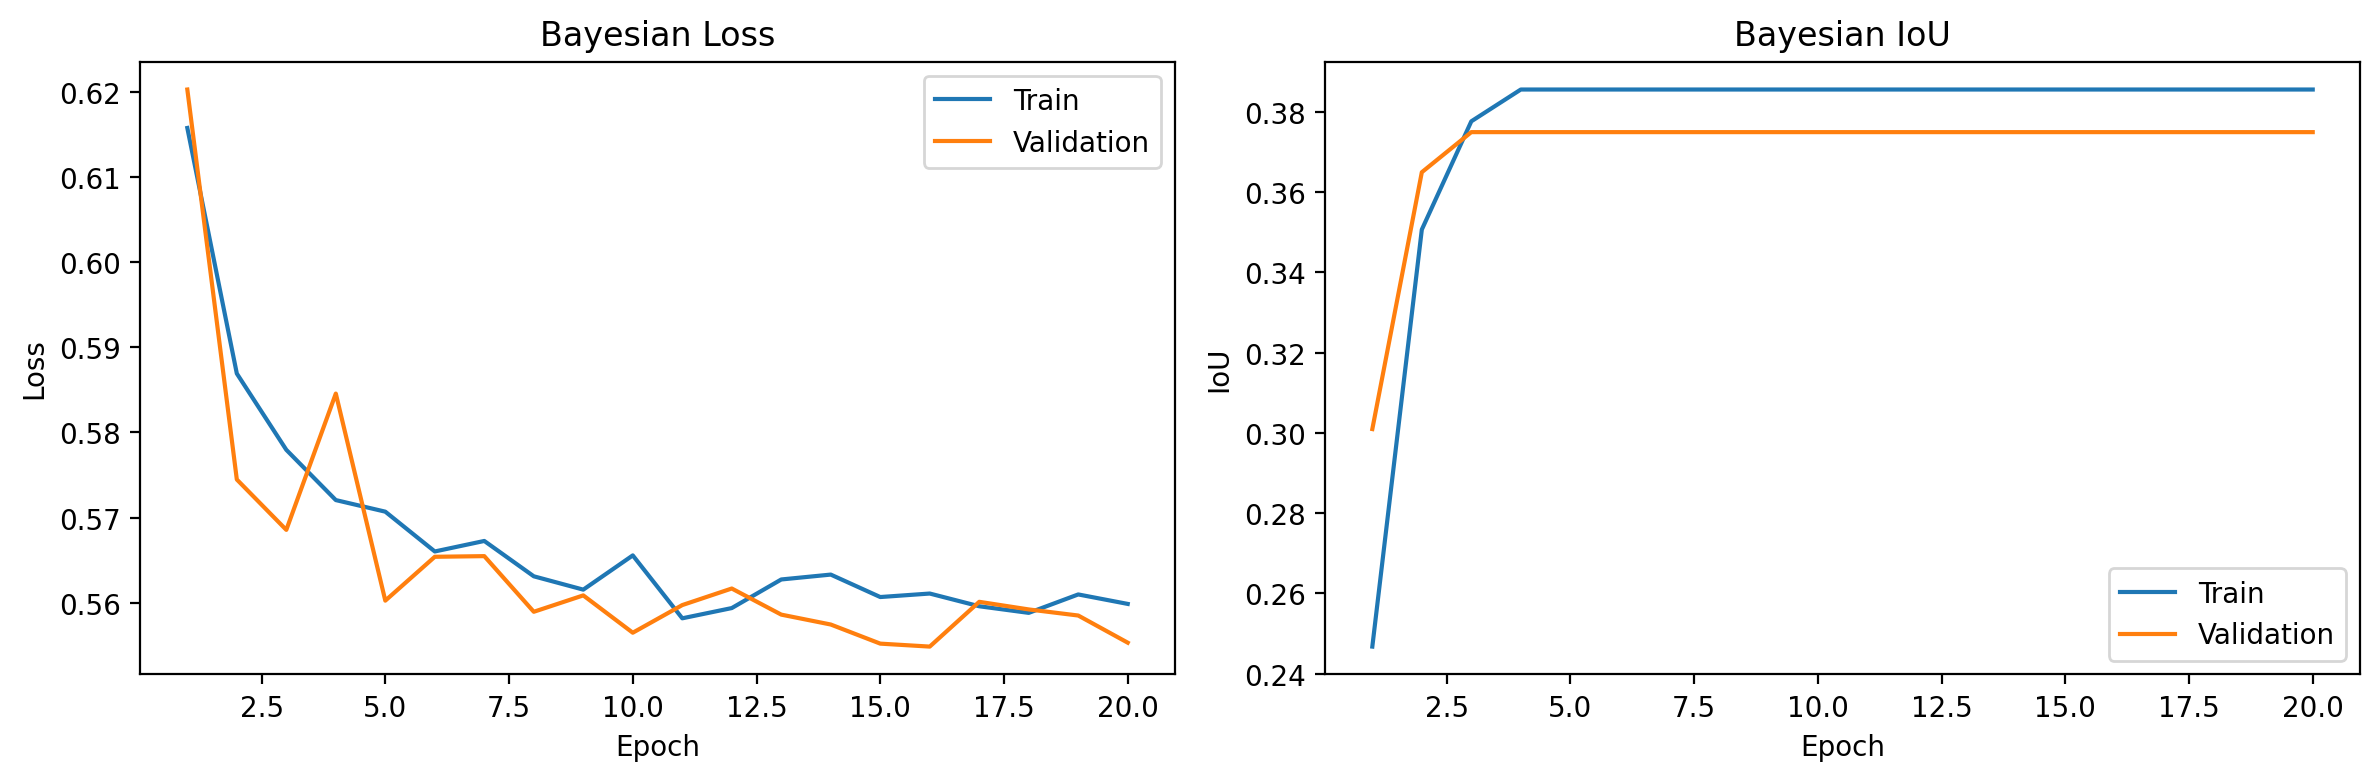

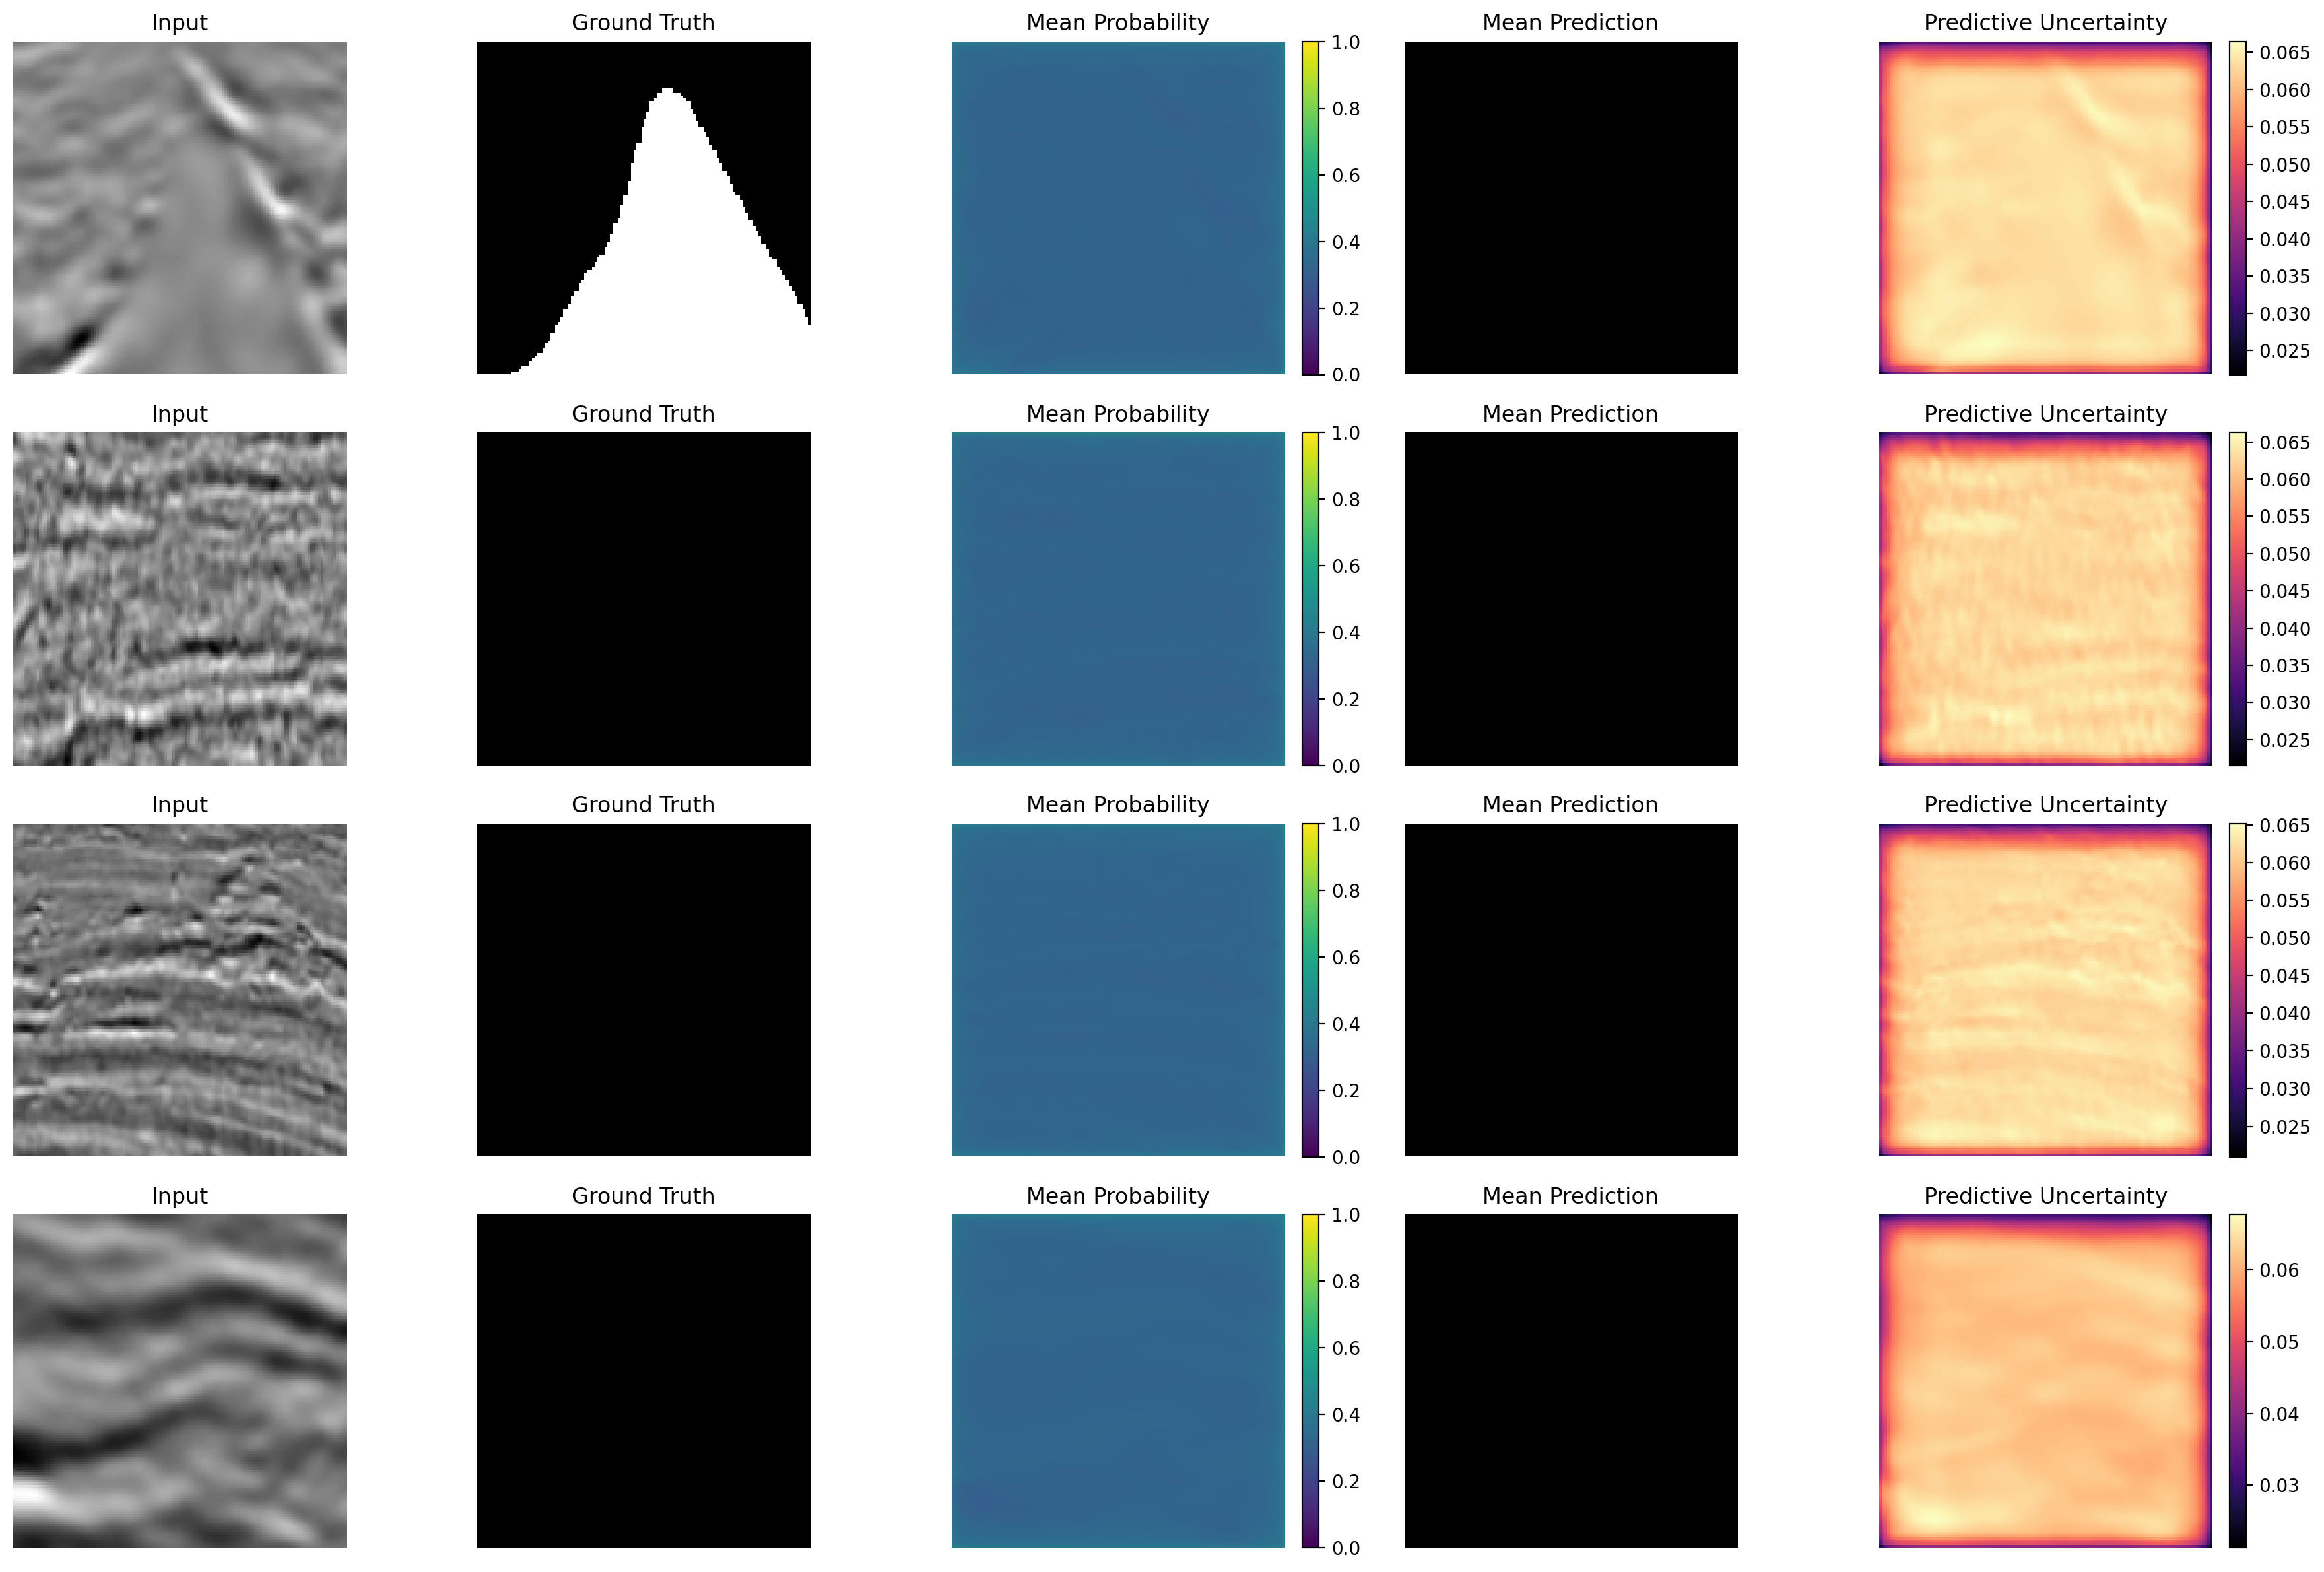

In [15]:
bayes_history_path = plot_history(bayes_history, FIGURE_DIR / "bayesian_history.png", title_prefix="Bayesian")
bayes_pred_path = plot_bayesian_predictions(
    bayes_images,
    bayes_masks,
    bayes_mean_probs,
    bayes_std_probs,
    FIGURE_DIR / "bayesian_predictions.png",
)
print(f"Saved Bayesian history figure to: {bayes_history_path}")
print(f"Saved Bayesian prediction figure to: {bayes_pred_path}")
display(Image(filename=str(bayes_history_path)))
display(Image(filename=str(bayes_pred_path)))
